# **MÁSTER BASKET DATA ANALYTICS - TRABAJO FINAL ASIGNATURA (TFA)**

---

## BLOQUE ESPECÍFICO: Análisis de Datos
## ASIGNATURA: **Machine Learning I**
## PROFESOR: Jaime Mallo Antelo

---

## ALUMNO: **Pablo Gómez Villamayor**
## CURSO: 2025-2026

---

## **TEMA**: Análisis-prevención de **lesiones** con datos **NBA**


---
---
---
---
---



## **COMENTARIOS GENERALES SOBRE LA ENTREGA**

He buscado realizar un **trabajo lo más completo posible**, en ambas tareas. De este modo, se ha tratado de cumplir todas las "*consideraciones*" o criterios de evaluación solicitados: Exploración de Datos, preprocesado, justificación de decisiones tomadas/modelos utilizados, etc. En todo momento, hemos buscado que el **código** sea **limpio, completo y mantenible**.

En favor de la completitud del código y de los ejercicios, se han utilizado diferentes algoritmos de Machine Learning en cada apartado. Es decir, no nos hemos limitado a generar un único modelo, sino que hemos intentado aplicar varios diferentes, y realizar un ajuste de hiperparámetros, para mejorar el desempeño de los mismos. 

Por otro lado, como se solicitaba de manera "*imprescindible*", el código ha sido debidamente comentado y las fuentes de información utilizadas han sido citadas al final del presente Notebook. 

En particular, en relación a cada tarea:

- **Tarea 1**: Se han implementado dos técnicas de clustering diferentes ('Kmeans' y 'Clustering jerárquico'), comparando el resultado. Una vez ejecutadas, se asignó una etiqueta coherente a cada grupo. 

- **Tarea 2**: Se han utilizado dos modelos diferentes, en concreto: árboles de decisión y redes neuronales ¿?. Se ha comparado el rendimiento de ambos modelos. Se ha tenido en cuenta el posible desbalanceo de clases. Por último, se han guardado/exportado los modelos, para poder ejecutarlos sin necesidad de repetir el proceso de entrenamiento.

---

## **FORMATO DEL NOTEBOOK** 

Vamos a dividir el código en varios apartados, de forma que se pueda identificar de forma clara el proceso seguido en el ejercicio. De esta forma, el presente notebook seguirá una estructura similar a la de los ejemplos propuestos en clase: Importación de librerías, carga, exploración y limpieza de datos, implementación de algoritmos de clustering, etc.

---
---
---
---
---


# **TAREA 1 - CLUSTERING**

## **ENUNCIADO** 

##### "Utiliza  alguna  técnica  de  clustering  vista  en  clase  para  generar  agrupaciones  que  nos  permitan analizar lesiones similares de forma conjunta. A partir de los grupos obtenidos, analiza cada uno de ellos y asigna un nombre representativo o descriptivo de la agrupación obtenida."


---
---
---

### **1. LIBRERÍAS**

En primer lugar, cargamos las librerías que se van a utilizar en el notebook.


In [ ]:
#Pandas: Dataset.
import pandas as pd
#Numpy: Matemáticas.
import numpy as np
#Sklearn: ML.
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

#Seaborn: Visualización.
import seaborn as sns
#Matplotlib: Visualización.
import matplotlib.pyplot as plt
#Warnings: Supresión de información de warnings por pantalla (prescindible, se utiliza para evitar una salida muy extensa).
import warnings
warnings.filterwarnings('ignore')
#Scipy: Implementación de algoritmos para python de código abierto.
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree

### **2. LECTURA DE DATOS**

A continuación, cargamos el dataset  “DatasetLesionesDeportivasImpacto.csv” en nuestro notebook. Nótese que el separador utilizado es la coma (",") y la primera fila del dataset corresponde a la cabecera.

In [2]:
df = pd.read_csv('DatasetLesionesDeportivasImpacto.csv', sep=',', header=0)

### **3. EXPLORACIÓN DE DATOS**

Exploramos los datos disponibles: el volumen de los mismos, tipos de variables, posible existencia de valores nulos, etc.

In [3]:
df

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,Predictib.,Coste,Longevidad
0,1,Rotura LCA,Mixta,30.0,50.0,40.0,8.0,24,12%,75%,Alta,Alto,5/5
1,2,Esguince Tobillo GI,Mixta,0.5,1.5,1.0,0.5,1,30%,98%,Alta,Bajo,1/5
2,3,Esguince Tobillo GII,Mixta,2.0,4.0,3.0,1.0,2,35%,95%,Alta,Bajo,1/5
3,4,Esguince Tobillo GIII,Mixta,6.0,10.0,8.0,2.0,4,40%,85%,Media,Medio,2/5
4,5,Rotura T. Aquiles,No Traum.,40.0,56.0,48.0,12.0,36,8%,60%,Alta,Alto,5/5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Sesamoideitis Crón.,No Traum.,4.0,16.0,10.0,4.0,8,55%,85%,Baja,Bajo,3/5
96,97,Fractura Radio Dist.,Traumática,8.0,12.0,10.0,3.0,4,5%,94%,Alta,Alto,1/5
97,98,Ruptura Polea Dedo,Mixta,6.0,16.0,11.0,4.0,6,20%,88%,Media,Medio,2/5
98,99,Osteopatía Pubis,No Traum.,8.0,24.0,16.0,8.0,12,65%,70%,M. Baja,Medio,4/5


In [4]:
df.shape

(100, 13)

Vemos que el dataset contiene 100 filas y 13 columnas. 

La primera columna es un identificador, de modo que tenemos 12 variables con las que trabajar. Para refrescar información, incluimos en el notebook el resumen de las variables del enunciado del problema:

"

- ID: Identificador único asignado a cada tipo de lesión o patología. 
- Patología (Lesión): Nombre de la lesión o condición médica que afecta al jugador. 
- Etiología: Causa o mecanismo que origina la lesión (por ejemplo, contacto, sobrecarga o 
traumatismo). 
- TL Min: Tiempo mínimo estimado de baja o recuperación asociado a la lesión. 
-  TL Max: Tiempo máximo estimado de baja o recuperación asociado a la lesión. 
-  TL Med: Tiempo medio estimado de recuperación basado en casos observados. 
-  RTP: Return To Play, probabilidad o facilidad estimada de que el jugador pueda volver a competir tras la lesión. 
-  RTPf: Return To Play final, evaluación final de la recuperación efectiva del jugador para volver a competir. 
-  RoR: Risk of Recurrence, probabilidad de que la lesión vuelva a producirse tras la recuperación. 
-  Success: Probabilidad o nivel de éxito esperado del proceso de recuperación o tratamiento. 
-  Predictib.: Predictibilidad de la evolución de la lesión y del tiempo de recuperación. 
-  Coste: Impacto económico o de recursos médicos asociado al tratamiento o recuperación de la 
lesión. 
-  Longevidad: Efecto potencial de la lesión sobre la duración de la carrera deportiva del jugador.

"



In [5]:
#Veamos información de las variables, su tipo etc.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  100 non-null    int64  
 1   Patología (Lesión)  100 non-null    str    
 2   Etiología           100 non-null    str    
 3   TL Min              100 non-null    float64
 4   TL Max              100 non-null    float64
 5   TL Med              100 non-null    float64
 6   RTP                 100 non-null    float64
 7   RTPf                100 non-null    int64  
 8   RoR                 100 non-null    str    
 9   Success             100 non-null    str    
 10  Predictib.          100 non-null    str    
 11  Coste               100 non-null    str    
 12  Longevidad          100 non-null    str    
dtypes: float64(4), int64(2), str(7)
memory usage: 10.3 KB


Vemos que algunas variables numéricas (RoR y Success) se han cargado como tipo 'str', cuando representan porcentajes. Eliminamos el símbolo de '%' y convertimos a tipo float.

In [6]:
df['RoR']=df['RoR'].str.replace('%', '').astype('float')
df['Success']=df['Success'].str.replace('%', '').astype('float')



Expresamos en 'tanto por 1' en lugar de 'tanto por 100', de modo que ya tengamos esas variables en forma de ratio, es decir, en una escala 0-1.

In [7]:
df['RoR_Scal']=round(df['RoR']/100,3)
df['Success_Scal']=round(df['Success']/100,3)

In [8]:
df

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,Predictib.,Coste,Longevidad,RoR_Scal,Success_Scal
0,1,Rotura LCA,Mixta,30.0,50.0,40.0,8.0,24,12.0,75.0,Alta,Alto,5/5,0.12,0.75
1,2,Esguince Tobillo GI,Mixta,0.5,1.5,1.0,0.5,1,30.0,98.0,Alta,Bajo,1/5,0.30,0.98
2,3,Esguince Tobillo GII,Mixta,2.0,4.0,3.0,1.0,2,35.0,95.0,Alta,Bajo,1/5,0.35,0.95
3,4,Esguince Tobillo GIII,Mixta,6.0,10.0,8.0,2.0,4,40.0,85.0,Media,Medio,2/5,0.40,0.85
4,5,Rotura T. Aquiles,No Traum.,40.0,56.0,48.0,12.0,36,8.0,60.0,Alta,Alto,5/5,0.08,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Sesamoideitis Crón.,No Traum.,4.0,16.0,10.0,4.0,8,55.0,85.0,Baja,Bajo,3/5,0.55,0.85
96,97,Fractura Radio Dist.,Traumática,8.0,12.0,10.0,3.0,4,5.0,94.0,Alta,Alto,1/5,0.05,0.94
97,98,Ruptura Polea Dedo,Mixta,6.0,16.0,11.0,4.0,6,20.0,88.0,Media,Medio,2/5,0.20,0.88
98,99,Osteopatía Pubis,No Traum.,8.0,24.0,16.0,8.0,12,65.0,70.0,M. Baja,Medio,4/5,0.65,0.70


Parece que no hay valores nulos. Antes de continuar, nos cercioramos de ello. Si los hubiera, habría que realizar un tratamiento adecuado, como vimos en clase. En nuestro caso, no será necesario.

In [9]:
df.isnull().sum()

ID                    0
Patología (Lesión)    0
Etiología             0
TL Min                0
TL Max                0
TL Med                0
RTP                   0
RTPf                  0
RoR                   0
Success               0
Predictib.            0
Coste                 0
Longevidad            0
RoR_Scal              0
Success_Scal          0
dtype: int64

Ahora, identificamos rangos, posibles valores extremos y coherencia en las variables.

In [10]:
df.describe()

,ID,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,RoR_Scal,Success_Scal
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,6.975000,14.120000,10.546000,3.39000,6.67000,29.390000,87.580000,0.293900,0.875800
std,29.011492,7.568667,11.829624,9.595984,2.62234,6.63181,18.082803,10.056587,0.180828,0.100566
min,1.000000,0.500000,1.500000,1.000000,0.50000,0.00000,2.000000,55.000000,0.020000,0.550000
25%,25.750000,2.000000,6.000000,4.500000,1.50000,2.00000,15.000000,82.000000,0.150000,0.820000
50%,50.500000,4.000000,10.000000,8.000000,3.00000,4.00000,25.000000,90.000000,0.250000,0.900000
75%,75.250000,8.000000,16.500000,12.250000,4.00000,8.00000,40.500000,95.000000,0.405000,0.950000
max,100.000000,44.000000,60.000000,52.000000,12.00000,40.00000,75.000000,100.000000,0.750000,1.000000


Parece que 'TL' está expresado en semanas, 'RTP' en una escala 0-12 y 'RTPf' en una escala 0-40.

Veamos rápidamente como se distribuyen los datos.

array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'TL Min'}>,
        <Axes: title={'center': 'TL Max'}>],
       [<Axes: title={'center': 'TL Med'}>,
        <Axes: title={'center': 'RTP'}>,
        <Axes: title={'center': 'RTPf'}>],
       [<Axes: title={'center': 'RoR'}>,
        <Axes: title={'center': 'Success'}>,
        <Axes: title={'center': 'RoR_Scal'}>],
       [<Axes: title={'center': 'Success_Scal'}>, <Axes: >, <Axes: >]],
      dtype=object)

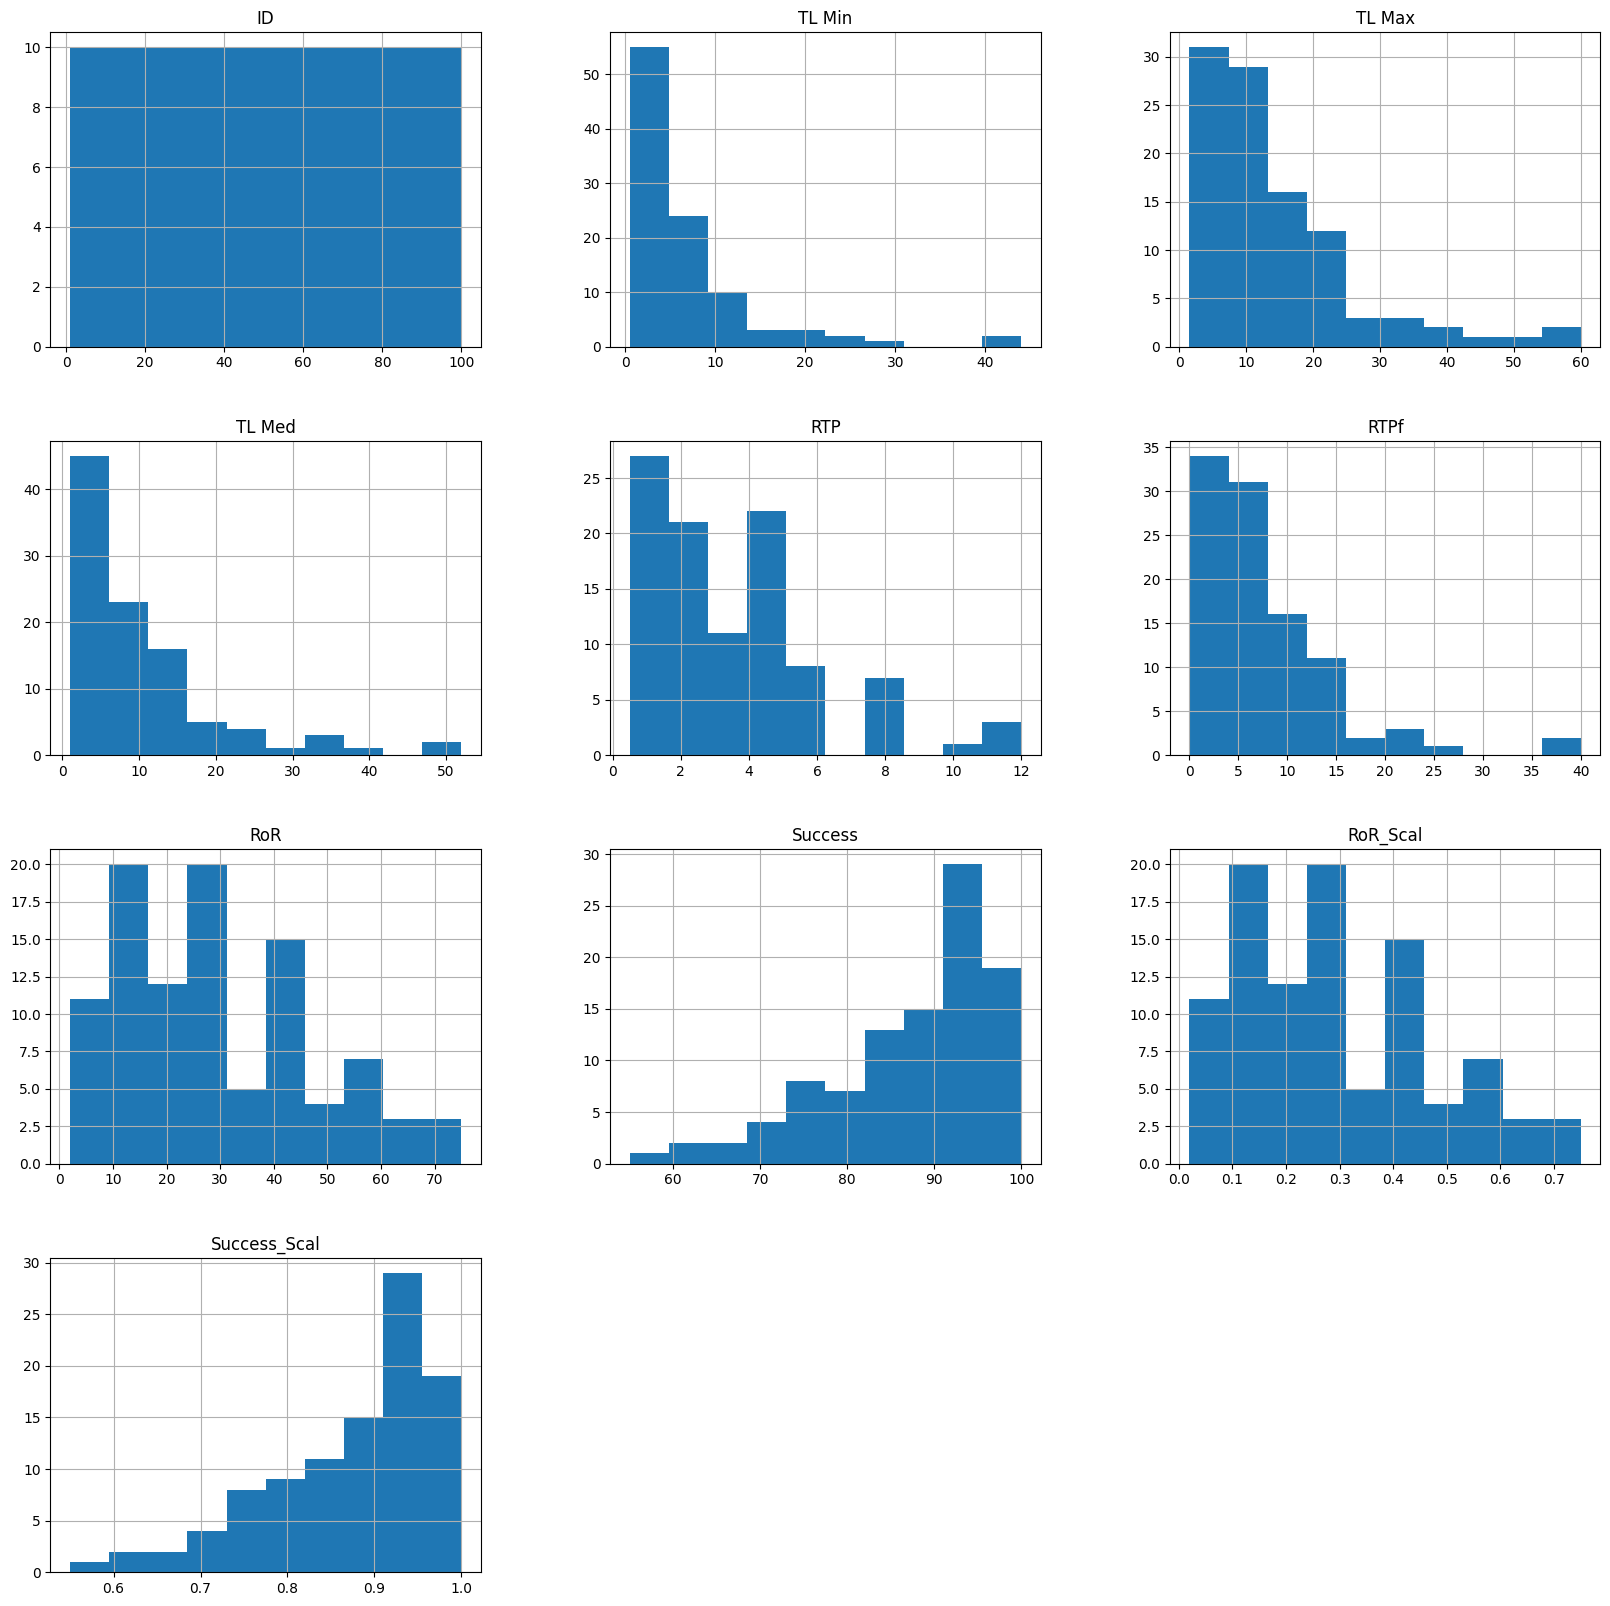

In [11]:
df.hist(figsize=(20,20))

### **4. PREPROCESADO DE DATOS: LIMPIEZA & TRANSFORMACIÓN**

In [12]:
df.columns

Index(['ID', 'Patología (Lesión)', 'Etiología', 'TL Min', 'TL Max', 'TL Med',
       'RTP', 'RTPf', 'RoR', 'Success', 'Predictib.', 'Coste', 'Longevidad',
       'RoR_Scal', 'Success_Scal'],
      dtype='str')

En primer lugar, la variable 'Longevidad' se expresa en una escala 1-5, pero el formato es un string del tipo '2/5'. Hay que transformar esto en un tipo float. Eliminamos el separador y realizamos la división. Guardamos el resultado en una nueva variable, 'Longevidad_Scal'.

In [13]:
# 1. Separamos por '/'. Con expand=True convertimos la lista resultante en columnas separadas
df[["num", "denom"]] = df["Longevidad"].str.split("/", expand=True)

# 2. Convertimos dichas columnas a tipo float y dividimos -> Así, ya lo tenemos en escala 0-1.
df["Longevidad_Scal"] = df["num"].astype(float) / df["denom"].astype(float)

# 3. Eliminamos las columnas auxiliares, pues no las necesitamos para nada más.
df = df.drop(columns=["num", "denom"])

Posteriormente, nos centramos en las variables categóricas: 'Predictib.' y 'Coste'.
Veamos los posibles valores que toman estas variables, y cómo se distribuyen (frecuencia de cada posible valor). 

In [14]:
variables_categoricas = ['Predictib.','Coste']

for col in variables_categoricas:
    conteos = df[col].value_counts()
    print(f"\nValores en la columna '{col}':")
    print(conteos)
    print(f"\n--------------------------------")



Valores en la columna 'Predictib.':
Predictib.
Alta        38
Media       32
Baja        22
Muy Baja     4
M. Baja      4
Name: count, dtype: int64

--------------------------------

Valores en la columna 'Coste':
Coste
Bajo        40
Medio       30
Alto        27
M. Alto      2
Muy Alto     1
Name: count, dtype: int64

--------------------------------


Se ha considerado ambas son variables categóricas nominales, no ordinales. No podemos establecer de manera evidente una relación numérica (de orden). No sabemos si la *distancia* entre un coste "bajo" y un coste "medio" es la misma que entr un coste "medio" y uno "alto". 

De esta manera, transformaremos las mencionadas variables categóricas usando pandas, como vimos en clase. Antes de esto, realizamos una puntualización.

---

Vemos que 'Predictib.' puede tomar los valores: {Alta, Media, Baja, Muy Baja, M.Baja}. He interpretado que "Muy Baja" y "M.Baja" representan lo mismo, por lo que no tiene sentido darle dos valores diferentes, y esto podría perjudicar el rendimiento del algoritmo.

Del mismo modo, observamos que 'Coste' puede tomar los valores: {Bajo, Medio, Alto, M. Alto , Muy Alto}. En este caso, interpretamos que "M. Alto" y "Muy Alto" representan lo mismo, y no hay porque por lo que no tiene sentido darle dos valores diferentes, y esto podría perjudicar el rendimiento del algoritmo.

En consecuencia, reemplazamos los valores para eliminar uno de los tipos repetidos y evitar redundancias que puedan perjudicar a nuestros modelos.


In [15]:
df['Predictib.']=df['Predictib.'].str.replace('M.', 'Muy')
df['Coste']=df['Coste'].str.replace('M.', 'Muy')

Reejecutamos el código previo y vemos que el reemplazo se ha ejecutado correctamente.

In [16]:
for col in variables_categoricas:
    conteos = df[col].value_counts()
    print(f"\nValores en la columna '{col}':")
    print(conteos)
    print(f"\n--------------------------------")


Valores en la columna 'Predictib.':
Predictib.
Alta        38
Media       32
Baja        22
Muy Baja     8
Name: count, dtype: int64

--------------------------------

Valores en la columna 'Coste':
Coste
Bajo        40
Medio       30
Alto        27
Muy Alto     3
Name: count, dtype: int64

--------------------------------


Efectivamente, ahora solo tenemos 4 posibles valores en cada una de las variables.

Ya no necesitamos limpiar más los datos. Pasamos a transformar las variables categóricas.

In [17]:
df=pd.get_dummies(data=df, columns=variables_categoricas)

In [18]:
df.columns

Index(['ID', 'Patología (Lesión)', 'Etiología', 'TL Min', 'TL Max', 'TL Med',
       'RTP', 'RTPf', 'RoR', 'Success', 'Longevidad', 'RoR_Scal',
       'Success_Scal', 'Longevidad_Scal', 'Predictib._Alta', 'Predictib._Baja',
       'Predictib._Media', 'Predictib._Muy Baja', 'Coste_Alto', 'Coste_Bajo',
       'Coste_Medio', 'Coste_Muy Alto'],
      dtype='str')

Una vez tratadas las variables categóricas y la variable 'Longevidad', realizamos el escalado de las variables numéricas. Realizamos el proceso de estandarizado en bloque, como vimos en clase.

In [19]:
variables_numericas = ['TL Min', 'TL Max', 'TL Med','RTP', 'RTPf']
variables_numericas_new=["{x}_Scal".format(x=x) for x in variables_numericas]

In [20]:
scaler = StandardScaler()
arr_scal = scaler.fit_transform(df[variables_numericas])

Añadimos las columnas estandarizadas en nuestro dataset. Como vimos en el ejemplo de 'C5_Clustering.ipynb', vamos a generar un dataset auxiliar y cruzarlo con el anterior por el número de fila.

In [21]:
#aux es el dataset auxiliar, que contiene las variables escaladas.
aux=pd.DataFrame(data=arr_scal, columns=variables_numericas_new)
aux['row']=np.arange(aux.shape[0])
df['row']=np.arange(df.shape[0])
#df_scal es el dataset con todas las variables (originales y escaladas).
df_scal=pd.merge(df, aux, on='row')

Veamos su aspecto.

In [22]:
df_scal.head(10)

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,...,Coste_Alto,Coste_Bajo,Coste_Medio,Coste_Muy Alto,row,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal
0,1,Rotura LCA,Mixta,30.0,50.0,40.0,8.0,24,12.0,75.0,...,True,False,False,False,0,3.057473,3.048343,3.084872,1.766828,2.626327
1,2,Esguince Tobillo GI,Mixta,0.5,1.5,1.0,0.5,1,30.0,98.0,...,False,True,False,False,1,-0.859811,-1.072188,-0.999803,-1.107621,-0.859277
2,3,Esguince Tobillo GII,Mixta,2.0,4.0,3.0,1.0,2,35.0,95.0,...,False,True,False,False,2,-0.660627,-0.859789,-0.790332,-0.915991,-0.707729
3,4,Esguince Tobillo GIII,Mixta,6.0,10.0,8.0,2.0,4,40.0,85.0,...,False,False,True,False,3,-0.129470,-0.350033,-0.266656,-0.532731,-0.404633
4,5,Rotura T. Aquiles,No Traum.,40.0,56.0,48.0,12.0,36,8.0,60.0,...,True,False,False,False,4,4.385366,3.558100,3.922754,3.299868,4.444904
5,6,Rotura Menisco,Mixta,8.0,16.0,12.0,4.0,8,15.0,88.0,...,True,False,False,False,5,0.136109,0.159724,0.152285,0.233789,0.201559
6,7,Rotura Isquiotibial,No Traum.,3.0,6.0,4.5,1.5,3,45.0,92.0,...,False,True,False,False,6,-0.527837,-0.689870,-0.633229,-0.724361,-0.556181
7,8,Fascitis Plantar,No Traum.,4.0,16.0,10.0,4.0,6,65.0,80.0,...,False,False,True,False,7,-0.395048,0.159724,-0.057185,0.233789,-0.101537
8,9,Frac. Estrés (5º Meta),No Traum.,10.0,18.0,14.0,4.0,6,25.0,82.0,...,True,False,False,False,8,0.401688,0.329642,0.361756,0.233789,-0.101537
9,10,Tendinitis Rotuliana,No Traum.,2.0,10.0,6.0,2.0,12,55.0,85.0,...,False,False,True,False,9,-0.660627,-0.350033,-0.476126,-0.532731,0.807751


In [23]:
df_scal.columns

Index(['ID', 'Patología (Lesión)', 'Etiología', 'TL Min', 'TL Max', 'TL Med',
       'RTP', 'RTPf', 'RoR', 'Success', 'Longevidad', 'RoR_Scal',
       'Success_Scal', 'Longevidad_Scal', 'Predictib._Alta', 'Predictib._Baja',
       'Predictib._Media', 'Predictib._Muy Baja', 'Coste_Alto', 'Coste_Bajo',
       'Coste_Medio', 'Coste_Muy Alto', 'row', 'TL Min_Scal', 'TL Max_Scal',
       'TL Med_Scal', 'RTP_Scal', 'RTPf_Scal'],
      dtype='str')

Ahora sí, hemos solucionado todos los inconvenientes encontrados De este modo, damos por finalizado el preprocesado de los datos. Vamos a seleccionar las variables que utilizaremos finalmente en los modelos, esto es: variables numéricas escaladas + variables categóricas transformadas:

In [24]:
#Variables de entrada. 
#También podríamos llamarlo "X" o "input_columns"
features = ['TL Min_Scal', 'TL Max_Scal','TL Med_Scal', 'RTP_Scal', 'RTPf_Scal',
            'RoR_Scal', 'Success_Scal', 'Longevidad_Scal', 'Predictib._Alta', 
            'Predictib._Baja','Predictib._Media', 'Predictib._Muy Baja', 'Coste_Alto', 
            'Coste_Bajo','Coste_Medio', 'Coste_Muy Alto']

#Variables de entrada, sin normalizar -> Para la interpretación de los clusters.
features_orig = ['TL Min', 'TL Max','TL Med', 'RTP', 'RTPf',
            'RoR', 'Success', 'Longevidad_Scal', 'Predictib._Alta', 
            'Predictib._Baja','Predictib._Media', 'Predictib._Muy Baja', 'Coste_Alto', 
            'Coste_Bajo','Coste_Medio', 'Coste_Muy Alto']

In [25]:
df_scal[features]

,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal,RoR_Scal,Success_Scal,Longevidad_Scal,Predictib._Alta,Predictib._Baja,Predictib._Media,Predictib._Muy Baja,Coste_Alto,Coste_Bajo,Coste_Medio,Coste_Muy Alto
0,3.057473,3.048343,3.084872,1.766828,2.626327,0.12,0.75,1.0,True,False,False,False,True,False,False,False
1,-0.859811,-1.072188,-0.999803,-1.107621,-0.859277,0.30,0.98,0.2,True,False,False,False,False,True,False,False
2,-0.660627,-0.859789,-0.790332,-0.915991,-0.707729,0.35,0.95,0.2,True,False,False,False,False,True,False,False
3,-0.129470,-0.350033,-0.266656,-0.532731,-0.404633,0.40,0.85,0.4,False,False,True,False,False,False,True,False
4,4.385366,3.558100,3.922754,3.299868,4.444904,0.08,0.60,1.0,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.395048,0.159724,-0.057185,0.233789,0.201559,0.55,0.85,0.6,False,True,False,False,False,True,False,False
96,0.136109,-0.180114,-0.057185,-0.149471,-0.404633,0.05,0.94,0.2,True,False,False,False,True,False,False,False
97,-0.129470,0.159724,0.047550,0.233789,-0.101537,0.20,0.88,0.4,False,False,True,False,False,False,True,False
98,0.136109,0.839399,0.571226,1.766828,0.807751,0.65,0.70,0.8,False,False,False,True,False,False,True,False


Sin más, pasamos ahora a la parte principal del ejercicio: la implementación de los modelos de clustering.

### **5. CLUSTERING**

En primer lugar, vamos a obtener el número k de grupos (o 'clusters'), mediante la **técnica del codo**. Como vimos en clase, la implementamos con la siguiente función.

In [26]:
def elbow(data, kmin, kmax):
  inertias = []
  for i in range(kmin, kmax):
      kmeans = KMeans(n_clusters=i, random_state=7)
      kmeans.fit(data)
      inertias.append(kmeans.inertia_)

  plt.plot(range(kmin, kmax), inertias, marker='o')
  plt.title('Elbow method')
  plt.xlabel('Number of clusters')
  plt.ylabel('Inertia')
  plt.show()

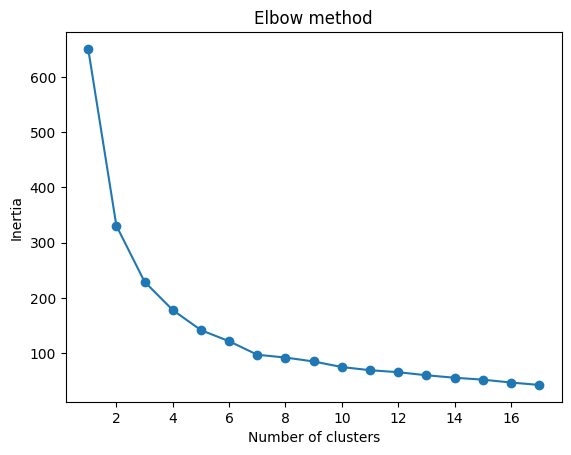

In [27]:
elbow(df_scal[features], 1, 18)

Apreciamos que el codo se encuentra entre 4-6 clúster. Vamos a tomar **k=5**.

### **5.1 CLUSTERING - KMEANS**

Lanzamos el algoritmo para dicho valor de k, como vimos en clase.

In [92]:
k=5
#Se define el modelo.
kmeans = KMeans(n_clusters=k, random_state=7)
#Se "entrena" el modelo y se lanza la predicción.
kmeans.fit_predict(df_scal[features].values)
#Se obtienen las etiquetas o clúster asignado a cada observación.
df_scal['cluster']=kmeans.labels_
y_clusters=kmeans.labels_

Veamos la distribución de los clusters entre las diferentes observaciones.

Text(0, 0.5, 'Frequency')

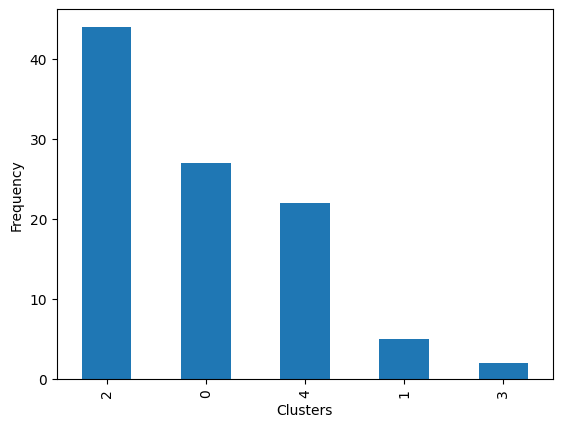

In [93]:
ax = df_scal['cluster'].value_counts().plot(kind='bar')
ax.set_xlabel("Clusters")
ax.set_ylabel("Frequency")

Se observa cierta **inhomogeneidad entre grupos**. 

Vemos 3 clusters mayoritarios, con más de 20 observaciones cada uno, y dos minoritarios, con menos de 5 observaciones cada uno. 

- Mayoritarios -> Clusters 0, 2 y 4.
- Minoritarios -> Clusters 1 y 3.

#### **5.1.1  ANÁLISIS DE RESULTADOS**


Vamos a analizar los grupos generados. Con este fin, vamos a graficar las variables 2 a 2, como hicimos en clase. Utilizamos las variables originales, pues la interpretación es más sencilla que con las normalizadas.

In [203]:
#sns.pairplot(df_scal, hue='cluster', size=3, vars=features_orig, kind='scatter', palette='muted')

El gráfico anterior tiene demasiadas variables y no podemos ver bien los grupos. Dejamos esa línea del código comentada.

 Nos limitamos a menos variables para la representación: las que consideramos más importantes.

In [204]:
features_plot = ['TL Med', 'RTPf','RoR', 'Success', 'Longevidad_Scal']


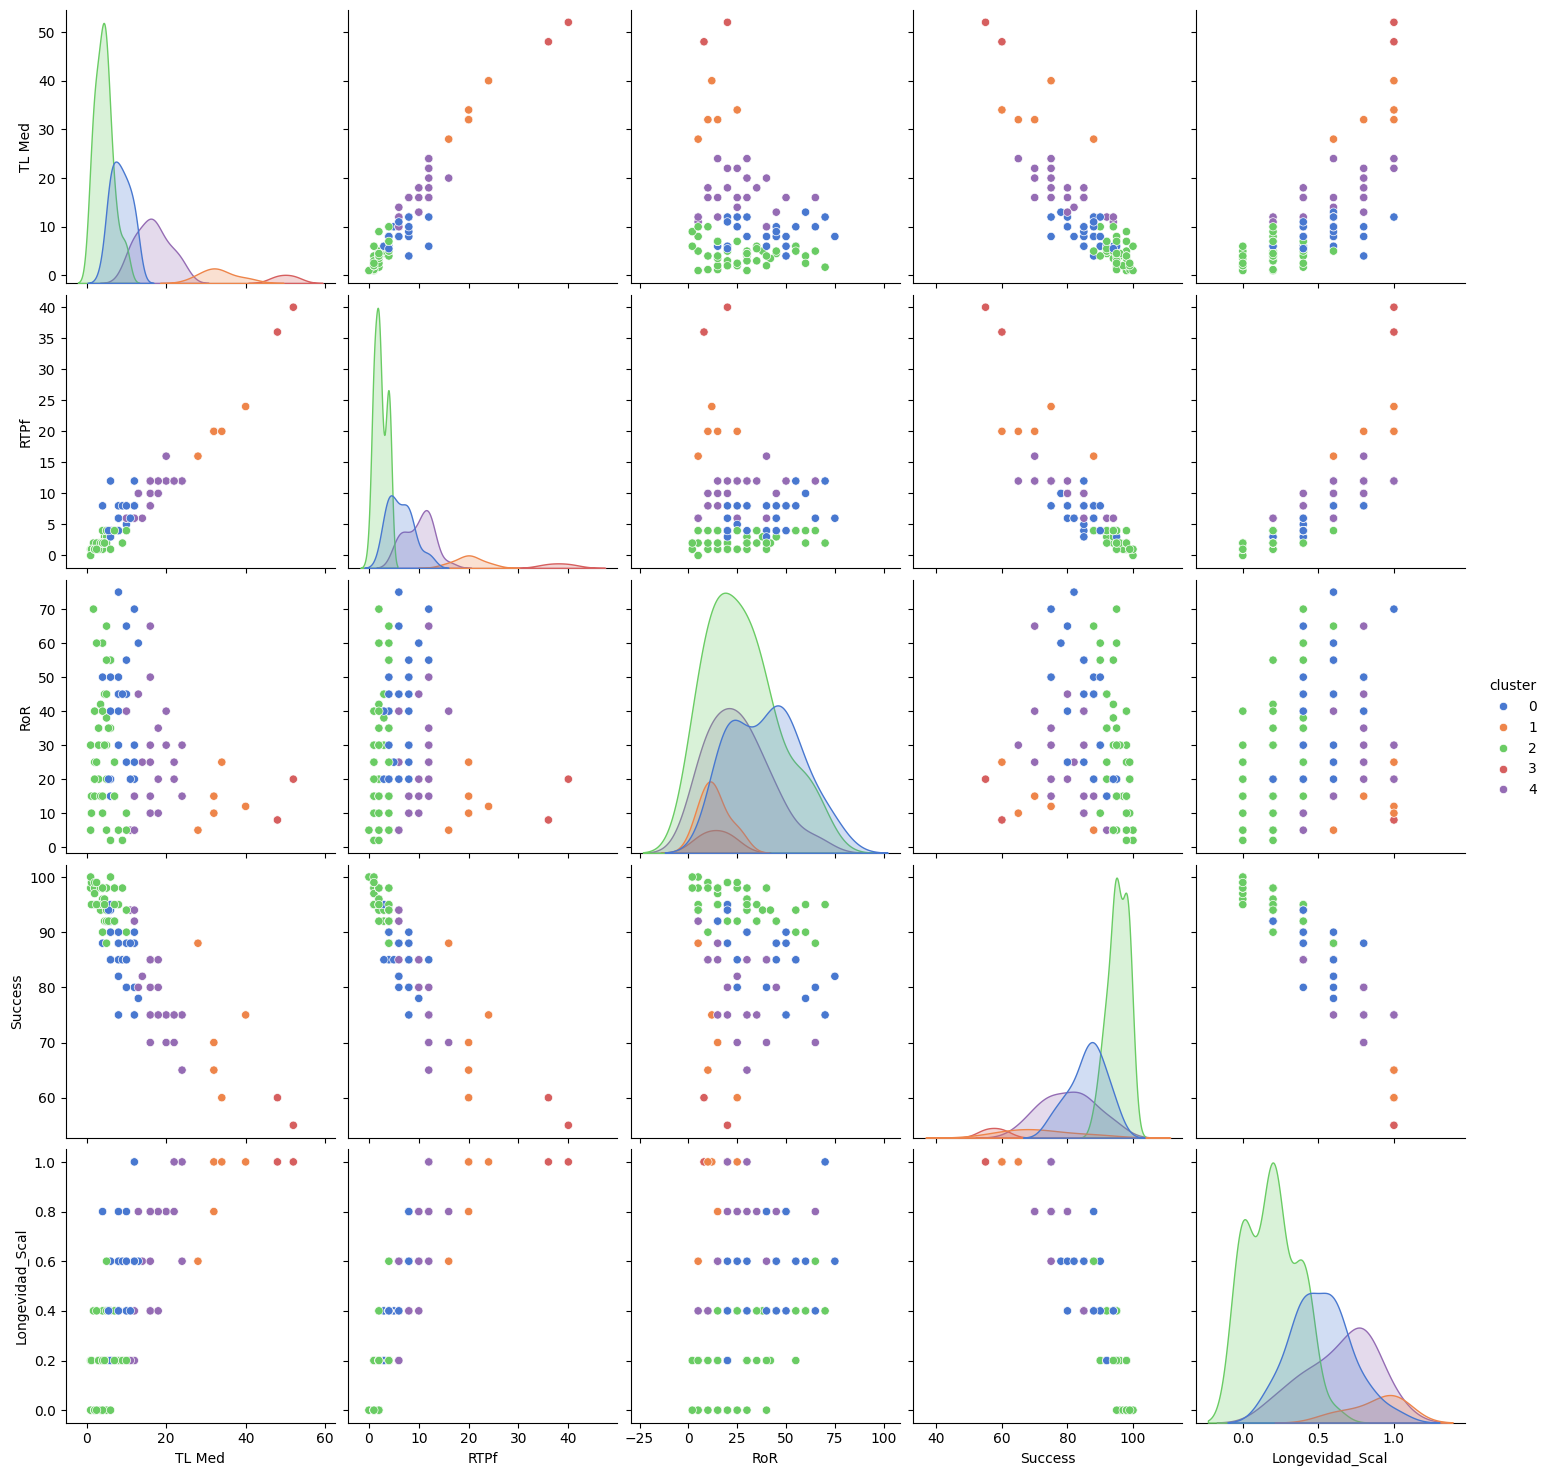

In [205]:
sns.pairplot(df_scal, hue='cluster', size=3, vars=features_plot, kind='scatter', palette='muted')

A partir de toda esta información, vamos a ver las **características principales de cada grupo**. 

Tras ello, realizaremos el 'etiquetaje' de acuerdo a lo observado.

In [206]:
df_scal['cluster'].value_counts()

cluster
2    44
0    27
4    22
1     5
3     2
Name: count, dtype: int64

Volumen de datos en cada grupo:

- Clúster 0 -> 27 Observaciones. 
- Clúster 1 ->  5 Observaciones.
- Clúster 2 -> 44 Observaciones.
- Clúster 3 ->  2 Observaciones.
- Clúster 4 -> 22 Observaciones.

In [207]:
features_analisis = ['TL Min', 'TL Max','TL Med', 'RTPf','RoR_Scal', 'Success_Scal', 'Longevidad_Scal']
            
#'Predictib.','Coste']

In [208]:
df_scal.groupby(['cluster'])[features_analisis].agg(['median','mean', 'std']).round(2)

TL Min              TL Max              TL Med                RTPf  \
        median   mean   std median   mean   std median   mean   std median   
cluster                                                                      
0          4.0   4.96  1.76   12.0  12.19  3.64    8.0   8.57  2.46    6.0   
1         24.0  23.60  4.10   40.0  42.80  5.93   32.0  33.20  4.38   20.0   
2          2.0   2.67  1.83    6.0   6.02  2.85    4.0   4.34  2.28    2.0   
3         42.0  42.00  2.83   58.0  58.00  2.83   50.0  50.00  2.83   38.0   
4         12.0  11.09  3.37   22.0  22.18  5.48   16.0  16.64  4.12   10.0   

         ...       RoR_Scal             Success_Scal              \
         ...   std   median  mean   std       median  mean   std   
cluster  ...                                                       
0        ...  2.54     0.40  0.40  0.17         0.88  0.86  0.06   
1        ...  2.83     0.12  0.13  0.07         0.70  0.72  0.11   
2        ...  1.22     0.25  0.28  0.18         0.95  0.95  0.03   
3        ...  2.83     0.14  0.14  0.08         0.57  0.57  0.04   
4        ...  2.79     0.25  0.25  0.16         0.80  0.80  0.08   

        Longevidad_Scal              
                 median  mean   std  
cluster                              
0                   0.6  0.52  0.19  
1                   1.0  0.88  0.18  
2                   0.2  0.20  0.16  
3                   1.0  1.00  0.00  
4                   0.7  0.65  0.23  

[5 rows x 21 columns]

Parece que los grupos cuentan con **tiempos de recuperación medios (TL Med) bien diferenciados entre sí**. De esta forma, cada grupo corresponde a una lesión de diferente duración/severidad.

Teniendo en cuenta la desviación típica (std), construimos unos rangos de tiempo (en semanas) aproximados para cada grupo:

    | [mean - std, mean + std] | 


- Clúster 0 -> [6, 10].
- Clúster 1 -> [29, 37].
- Clúster 2 -> [2, 6].
- Clúster 3 -> [47, 53].
- Clúster 4 -> [12, 20].

---

Veamos los valores medios de las siguientes variables: TL Med (tiempo medio estimado de recuperación, en semanas), RoR_Scal (ratio de recaída en la lesión, "Risk of Recurrence"), Success_Scal (Ratio de éxito de la recuperación) y Longevidad_Scal (Ratio del potencial efecto negativo de de la lesión sobre la duración de la carrera deportiva del jugador. Más negativo al acercarse al valor 1).

In [209]:
df_scal.groupby(['cluster'])[['TL Med', 'RoR_Scal','Success_Scal','Longevidad_Scal']].agg(['mean']).round(2)

,TL Med,RoR_Scal,Success_Scal,Longevidad_Scal
,mean,mean,mean,mean
cluster,,,,
0,8.57,0.40,0.86,0.52
1,33.20,0.13,0.72,0.88
2,4.34,0.28,0.95,0.20
3,50.00,0.14,0.57,1.00
4,16.64,0.25,0.80,0.65


                  | TL Med (semanas) | RoR_Scal (0-1) |  Success_Scal  (0-1) | Longevidad (0-1) | 

- Clúster 0 -> Duración media-baja | Riesgo recaída alto | Éxito alto     | Efecto en longevidad medio.
- Clúster 1 -> Duración alta       | Riesgo recaída bajo | Éxito medio    | Efecto en longevidad alto.
- Clúster 2 -> Duración baja       | Riesgo recaída medio| Éxito muy alto | Efecto en longevidad muy bajo.
- Clúster 3 -> Duración muy alta   | Riesgo recaída bajo | Éxito bajo     | Efecto en longevidad muy alto.
- Clúster 4 -> Duración media      | Riesgo recaida medio| Éxito alto     | Efecto en longevidad medio.

In [210]:
variables_categoricas_transf = ['Predictib._Alta', 'Predictib._Baja','Predictib._Media', 
                                'Predictib._Muy Baja', 'Coste_Alto', 'Coste_Bajo','Coste_Medio', 
                                'Coste_Muy Alto']

resumen_clusters = df_scal.groupby('cluster')[variables_categoricas_transf].mean().round(2)

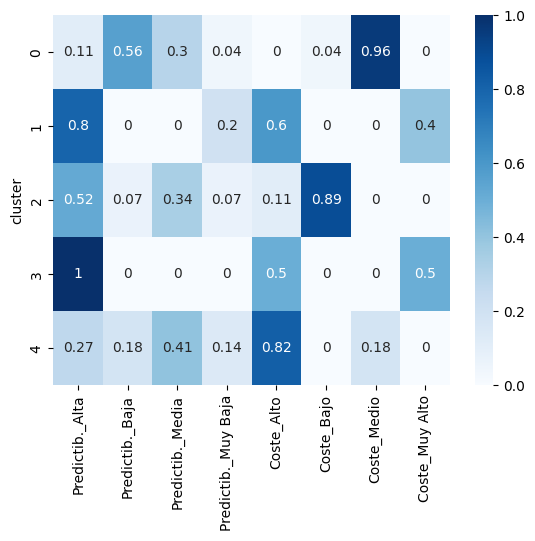

In [211]:
sns.heatmap(resumen_clusters, annot=True, cmap="Blues")
plt.show()

Mayoritariamente, respecto a predictibilidad/coste de la lesión, podemos anticipar el resultado gracias a nuestro conocimiento experto. Por lo general, las lesiones de mayor duración serán más costosas de recuperar (recursos económicos/médicos), y su impacto en el equipo supondrá mayor coste (coste asociado a que el jugador no esté jugando, salario invertido en ese jugador, menor número de venta de entradas/merchandising). Observamos que los valores de coste son coherentes con los grupos anteriores: Los clusters 0,2 y 4 (lesiones más leves/cortas) supondrán costes menores que los clústers 1 y 3 (lesiones más graves/largas).


                  | Predictibilidad | Coste |  

- Clúster 0 -> | Baja       | Medio
- Clúster 1 -> | Alta       | Alto-Muy alto
- Clúster 2 -> | Alta-Media | Bajo
- Clúster 3 -> | ALTA       | Alto-Muy alto
- Clúster 4 -> | Media      | Alto-Medio

Para terminar, veamos algunos ejemplos de lesiones muy graves (grupos 1 y 3).

In [212]:
df_cluster_1 = df_scal[df_scal['cluster'] == 1]
df_cluster_3 = df_scal[df_scal['cluster'] == 3]

In [213]:
df_cluster_1


,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,...,Coste_Medio,Coste_Muy Alto,row,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal,cluster,cluster_jerarquico
0,1,Rotura LCA,Mixta,30.0,50.0,40.0,8.0,24,12.0,75.0,...,False,False,0,3.057473,3.048343,3.084872,1.766828,2.626327,1,0
26,27,Rotura LCP Rodilla,Traumática,24.0,40.0,32.0,8.0,20,15.0,70.0,...,False,False,26,2.260737,2.198749,2.246990,1.766828,2.020135,1,0
64,65,Rotura Tendón Cuádr.,Traumática,24.0,40.0,32.0,10.0,20,10.0,65.0,...,False,True,64,2.260737,2.198749,2.246990,2.533348,2.020135,1,0
72,73,Fractura de Tibia,Traumática,20.0,36.0,28.0,8.0,16,5.0,88.0,...,False,True,72,1.729580,1.858912,1.828049,1.766828,1.413943,1,0
79,80,Osteocondritis Disec.,Mixta,20.0,48.0,34.0,12.0,20,25.0,60.0,...,False,False,79,1.729580,2.878425,2.456461,3.299868,2.020135,1,4


In [214]:
df_cluster_3

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,...,Coste_Medio,Coste_Muy Alto,row,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal,cluster,cluster_jerarquico
4,5,Rotura T. Aquiles,No Traum.,40.0,56.0,48.0,12.0,36,8.0,60.0,...,False,False,4,4.385366,3.558100,3.922754,3.299868,4.444904,3,2
27,28,Triada Completa,Traumática,44.0,60.0,52.0,12.0,40,20.0,55.0,...,False,True,27,4.916523,3.897938,4.341695,3.299868,5.051096,3,2


Efectivamente, observamos lesiones graves y algunas muy conocidas como son la rotura de LCA (Ligamento Cruzado Anterior. Ejemplo: Derrick Rose) o Rotura del Tendón de Aquiles (Ejemplo: Kobe Bryant o recientemente Jayson Tatum).

Los clústers 1 y 3 son los más similares entre si, a nivel de gravedad de lesiones. A la vista de los datos, parece que el grupo 3 corresponde a lesiones de duración aún más larga y potencialmente más peligrosas. Por ejemplo, a nivel de lesión de rodilla, la "triada completa" (grupo 3) es más grave que la "Rotura LCA".

---


A continuación, veamos algunos ejemplos del resto de grupos:

In [215]:
df_cluster_0 = df_scal[df_scal['cluster'] == 0]
df_cluster_2 = df_scal[df_scal['cluster'] == 2]
df_cluster_4 = df_scal[df_scal['cluster'] == 4]

In [216]:
df_cluster_0.head(5)

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,...,Coste_Medio,Coste_Muy Alto,row,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal,cluster,cluster_jerarquico
3,4,Esguince Tobillo GIII,Mixta,6.0,10.0,8.0,2.0,4,40.0,85.0,...,True,False,3,-0.129470,-0.350033,-0.266656,-0.532731,-0.404633,0,1
7,8,Fascitis Plantar,No Traum.,4.0,16.0,10.0,4.0,6,65.0,80.0,...,True,False,7,-0.395048,0.159724,-0.057185,0.233789,-0.101537,0,1
9,10,Tendinitis Rotuliana,No Traum.,2.0,10.0,6.0,2.0,12,55.0,85.0,...,True,False,9,-0.660627,-0.350033,-0.476126,-0.532731,0.807751,0,1
10,11,Pubalgia,No Traum.,6.0,20.0,13.0,4.0,10,60.0,78.0,...,True,False,10,-0.129470,0.499561,0.257020,0.233789,0.504655,0,3
17,18,Edema Óseo,Mixta,8.0,16.0,12.0,2.0,8,20.0,88.0,...,True,False,17,0.136109,0.159724,0.152285,-0.532731,0.201559,0,1


In [217]:
df_cluster_2.head(5)

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,...,Coste_Medio,Coste_Muy Alto,row,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal,cluster,cluster_jerarquico
1,2,Esguince Tobillo GI,Mixta,0.5,1.5,1.0,0.5,1,30.0,98.0,...,False,False,1,-0.859811,-1.072188,-0.999803,-1.107621,-0.859277,2,1
2,3,Esguince Tobillo GII,Mixta,2.0,4.0,3.0,1.0,2,35.0,95.0,...,False,False,2,-0.660627,-0.859789,-0.790332,-0.915991,-0.707729,2,1
6,7,Rotura Isquiotibial,No Traum.,3.0,6.0,4.5,1.5,3,45.0,92.0,...,False,False,6,-0.527837,-0.689870,-0.633229,-0.724361,-0.556181,2,1
12,13,Lumbalgia Mecánica,No Traum.,0.5,3.0,1.7,1.0,2,70.0,95.0,...,False,False,12,-0.859811,-0.944749,-0.926488,-0.915991,-0.707729,2,1
14,15,Fractura Escafoides,Traumática,8.0,12.0,10.0,2.0,4,10.0,90.0,...,False,False,14,0.136109,-0.180114,-0.057185,-0.532731,-0.404633,2,1


In [218]:
df_cluster_4.head(5)

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,...,Coste_Medio,Coste_Muy Alto,row,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal,cluster,cluster_jerarquico
5,6,Rotura Menisco,Mixta,8.0,16.0,12.0,4.0,8,15.0,88.0,...,False,False,5,0.136109,0.159724,0.152285,0.233789,0.201559,4,1
8,9,Frac. Estrés (5º Meta),No Traum.,10.0,18.0,14.0,4.0,6,25.0,82.0,...,False,False,8,0.401688,0.329642,0.361756,0.233789,-0.101537,4,1
11,12,Luxación Hombro,Traumática,12.0,20.0,16.0,4.0,8,30.0,85.0,...,False,False,11,0.667266,0.499561,0.571226,0.233789,0.201559,4,1
13,14,Hernia Discal L5-S1,No Traum.,12.0,28.0,20.0,6.0,16,40.0,70.0,...,False,False,13,0.667266,1.179237,0.990167,1.000308,1.413943,4,3
20,21,Desgarro Labrum,Mixta,18.0,30.0,24.0,6.0,12,15.0,75.0,...,False,False,20,1.464002,1.349155,1.409108,1.000308,0.807751,4,3


#### **5.1.2  ASIGNACIÓN DE ETIQUETAS**


Con toda esta información, ya tenemos suficiente información para asignar una etiqueta a cada grupo:

- **Clúster 0: "LESIÓN LEVE"**

        - Lesiones leves, duración media-baja. 
        - Alto riesgo de recaída, pero alta tasa de recuperación. 
        - Efecto medio sobre la longevidad. 
        - Coste económico bajo. 
        - Etiqueta: "LESIÓN LEVE". 
        - Ejemplos: Esguince Tobillo Grado 3, fascitis plantar.

---

- **Clúster 1: "LESIÓN GRAVE"**

        -Lesiones muy graves, larga duración. 
        - Bajo riesgo de recaída, pero éxito de recuperación medio. 
        - Potencialmente muy peligrosas para la carrera del jugador. 
        - Coste económico muy alto. 
        - Etiqueta: "LESIÓN GRAVE". 
        - Ejemplos: Rotura LCA, Fractura de Tibia.

---

- **Clúster 2: "LESIÓN MUY LEVE"**

        - Lesiones muy leves, duración corta. 
        - Riesgo de recaida medio, pero tasa de recuperación muy alta. 
        - Muy bajo efecto en la longevidad. 
        - Coste económico muy bajo. 
        - Etiqueta: "LESIÓN MUY LEVE". 
        - Ejemplos: Esguince Tobillo Grado 1 y 2, rotura Isquio.

Es coherente que el esguince de tobillo de grado 2 pertenezca al clúster 2 ("lesión muy leve"), ya que es menos grave que un esguince de tobillo de grado 3 ("lesión leve"). Parece que nuestro clustering funciona bien a la hora de etiquetar lesiones similares pero de diferente gravedad.

---

- **Clúster 3: "LESIÓN MUY GRAVE"**

        - Lesiones muy graves, larga duración.
        - Bajo riesgo de recaída, pero bajo éxito de recuperación.
        - Efecto en la longevidad muy alto. Lesiones de tipo "carrer-ending". 
        - Coste económico muy alto. 
        - Etiqueta: "LESIÓN MUY GRAVE". 
        ---
        - **Ejemplos: Rotura tendón de Aquiles y Triada Completa

**CURIOSIDAD SOBRE EL GRUPO 3** Solo existen dos lesiones en este grupo. La última, "Triada Completa". también se conoce como "tríada de O'Donoghue", y es una de las lesiones de rodilla más graves y complejas. Consiste en la rotura simultánea de tres estructuras anatómicas importantes: Ligamento cruzado anterior (LCA), Ligamento lateral interno o colateral medial (LLI o LCM) y Menisco interno o medial. Por eso comentamos anteriormente que esta lesión (grupo 3) es más grave que la rotura de LCA (grupo 1). De nuevo, parece que el algoritmo distingue bien la gravedad de lesiones similares (i.e. que afectan a la misma estructura anatómica) pero con gravedad diferente.

---

- **Clúster 4: "LESIÓN MEDIA" o "LESIÓN DE GRAVEDAD MEDIA"**

        - Lesiones de gravedad media, media duración. 
        - Riesgo de recaída medio, pero alto éxito en la recuperación. 
        - Efecto en la longevidad medio. Es el grupo más "equilibrado". 
        - Etiqueta: "LESIÓN DE GRAVEDAD MEDIA". Ejemplos: Rotura menisco, Luxación hombro.

### **5.2 CLUSTERING - CLUSTERING JERÁRQUICO**


Vamos a implementar este otro tipo de clustering, de acuerdo con el ejemplo visto en clase.

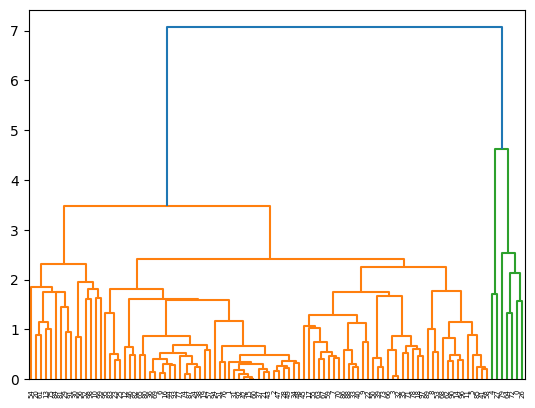

In [187]:
linkage_data = linkage(df_scal[features], method='average', metric='euclidean')
dendrogram(linkage_data)
plt.show()

Si cortamos a altura 2.5, obtendremos exactamente k=5 clústers, como antes.

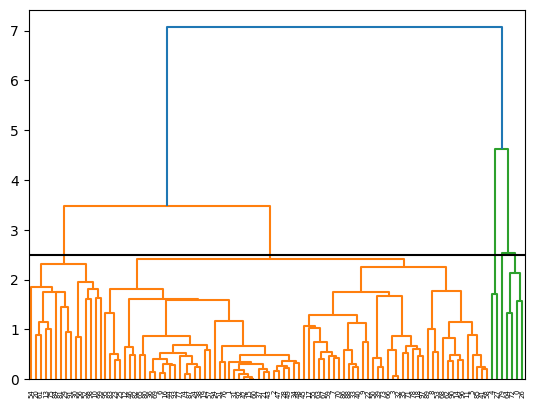

In [188]:
distancia=2.5
dendrogram(linkage_data)
plt.axhline(y=distancia, c='k')
plt.show()

Generamos los grupos.

In [189]:
clusters = cut_tree(linkage_data, height=2.5)
cluster_ids = [c[0] for c in clusters]

Los añadimos al dataframe, en una nueva variable de clustering, pero que NO sobreescriba a la anterior, para poder compararlas.

In [190]:
df_scal['cluster_jerarquico']=cluster_ids

Como antes, graficamos 2 a 2 las variables.

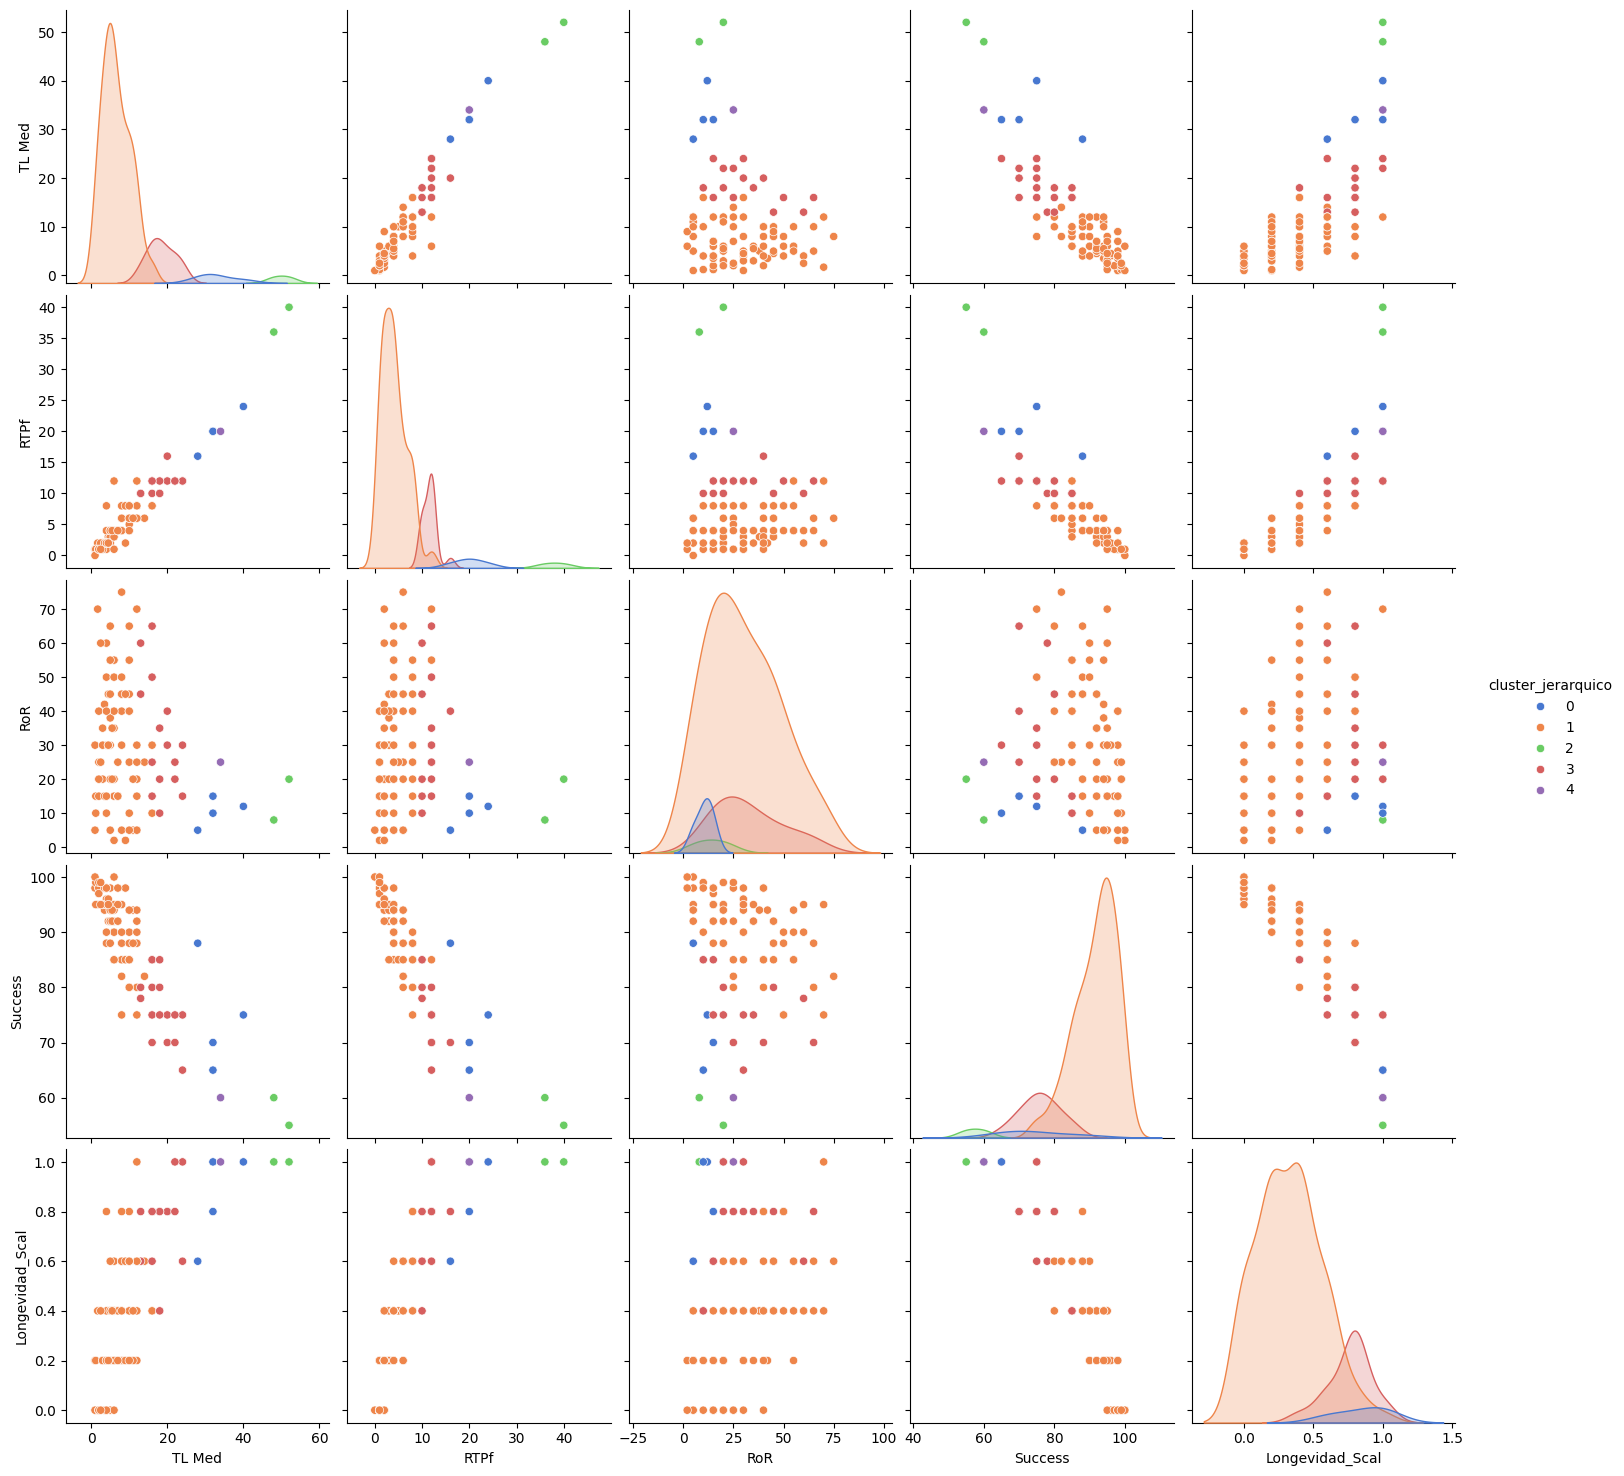

In [191]:
sns.pairplot(df_scal, hue='cluster_jerarquico', size=3, vars=features_plot, kind='scatter', palette='muted')

Repetimos rápidamente el análisis realizado para KMEANS, pero sin repetir todas las explicaciones.

In [196]:
df_scal['cluster_jerarquico'].value_counts()


cluster_jerarquico
1    78
3    15
0     4
2     2
4     1
Name: count, dtype: int64

Salta a la vista que los grupos son muy inhomogéneos, más que con el algoritmo anterior. 

Además, hay un grupo con solo 2 lesiones, y otro con solo una. Veamos cuáles son:

In [199]:
df_scal[df_scal['cluster_jerarquico'] == 4]

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,...,Coste_Medio,Coste_Muy Alto,row,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal,cluster,cluster_jerarquico
79,80,Osteocondritis Disec.,Mixta,20.0,48.0,34.0,12.0,20,25.0,60.0,...,False,False,79,1.72958,2.878425,2.456461,3.299868,2.020135,1,4


Vemos como este algoritmo jerárquico ha separado la "Osteocondritis" del resto de lesiones.

In [200]:
df_scal[df_scal['cluster_jerarquico'] == 2]

,ID,Patología (Lesión),Etiología,TL Min,TL Max,TL Med,RTP,RTPf,RoR,Success,...,Coste_Medio,Coste_Muy Alto,row,TL Min_Scal,TL Max_Scal,TL Med_Scal,RTP_Scal,RTPf_Scal,cluster,cluster_jerarquico
4,5,Rotura T. Aquiles,No Traum.,40.0,56.0,48.0,12.0,36,8.0,60.0,...,False,False,4,4.385366,3.558100,3.922754,3.299868,4.444904,3,2
27,28,Triada Completa,Traumática,44.0,60.0,52.0,12.0,40,20.0,55.0,...,False,True,27,4.916523,3.897938,4.341695,3.299868,5.051096,3,2


Por otro lado, volvemos a tener el grupo de las "LESIONES MUY GRAVES" formado por Tendón de Aquiles y Triada Completa. Es decir, ambos algoritmos de clustering implementados han distinguido estos grupos de manera exacta. El clúster 3 de KMEANS es exactamente el mismo que el clúster 2 de Clustering jerárquico.

In [197]:

df_scal.groupby(['cluster_jerarquico'])[features_analisis].agg(['median','mean', 'std']).round(2)

TL Min              TL Max              TL Med         \
                   median   mean   std median   mean   std median   mean   
cluster_jerarquico                                                         
0                    24.0  24.50  4.12   40.0  41.50  5.97   32.0  33.00   
1                     4.0   4.07  2.69    8.0   9.08  4.78    6.0   6.57   
2                    42.0  42.00  2.83   58.0  58.00  2.83   50.0  50.00   
3                    12.0  11.87  3.66   24.0  24.93  4.20   18.0  18.40   
4                    20.0  20.00   NaN   48.0  48.00   NaN   34.0  34.00   

                           RTPf  ...       RoR_Scal             Success_Scal  \
                     std median  ...   std   median  mean   std       median   
cluster_jerarquico               ...                                           
0                   5.03   20.0  ...  3.27     0.11  0.10  0.04         0.72   
1                   3.64    4.0  ...  2.64     0.30  0.30  0.18         0.93   
2                   2.83   38.0  ...  2.83     0.14  0.14  0.08         0.57   
3                   3.54   12.0  ...  1.55     0.30  0.32  0.17         0.75   
4                    NaN   20.0  ...   NaN     0.25  0.25   NaN         0.60   

                               Longevidad_Scal              
                    mean   std          median  mean   std  
cluster_jerarquico                                          
0                   0.74  0.10             0.9  0.85  0.19  
1                   0.92  0.06             0.4  0.33  0.23  
2                   0.57  0.04             1.0  1.00  0.00  
3                   0.76  0.06             0.8  0.76  0.15  
4                   0.60   NaN             1.0  1.00   NaN  

[5 rows x 21 columns]

Llama la atención que hay dos grupos con duración media de lesión muy similar (clusters 0 y 4, alrededor de 33-34 semanas, duración media-alta). El clúster 1 corresponde a lesiones de baja duración. El clúster 2 corresponde a lesiones muy graves, de muy alta duración. Y el clúster 3 a lesiones de duración media. 

Quizás este modelo ha utilizado otros criterios de clasificación, pues los grupos no están tan diferenciados respecto a la duración media de las lesiones como con el clustering de KMEANS. 

In [198]:

df_scal.groupby(['cluster_jerarquico'])[['TL Med', 'RoR_Scal','Success_Scal','Longevidad_Scal']].agg(['mean']).round(2)

,TL Med,RoR_Scal,Success_Scal,Longevidad_Scal
,mean,mean,mean,mean
cluster_jerarquico,,,,
0,33.00,0.10,0.74,0.85
1,6.57,0.30,0.92,0.33
2,50.00,0.14,0.57,1.00
3,18.40,0.32,0.76,0.76
4,34.00,0.25,0.60,1.00


In [201]:
resumen_clusters_jerarquico = df_scal.groupby('cluster_jerarquico')[variables_categoricas_transf].mean().round(2)


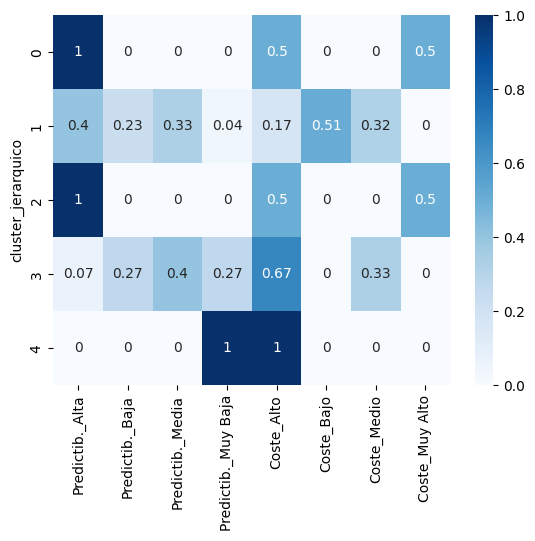

In [202]:
sns.heatmap(resumen_clusters_jerarquico, annot=True, cmap="Blues")
plt.show()

### **6. COMPARATIVA ENTRE MODELOS - CONCLUSIÓN**

Ya hemos ido comentado las diferencias entre algoritmos anteriormente en el notebook. Para finalizar el ejercicio, simplemente resaltamos que el segundo algoritmo (clustering jerárquico) ha distinguido 5 grupos, pero uno de ellos muy númeroso. Los grupos generados de esta forma no son tan homogéneos como los del primer algoritmo (kmeans).

Existen similitudes entre los grupos de ambos modelos, pero considero que la división del segundo es menos lógica que la del primero de los algoritmos. Así, considero que los grupos de KMEANS son más coherentes, y sería con el resultado que me quedaría.

El detalle de que dos clústers de distintos modelos coincidan exactamente me ha llamado la atención. Aunque los modelos sean diferentes, son capaces de reconocer del mismo modo ciertos patrones. 

Por último, cabe comentar que podría ser interesante repetir el proceso de clustering, pero probando con k=4 clases o con k=6 clases. Podríamos analizar cómo ambos algoritmos realizan los nuevos grupos, como se diferencian las nuevas clases de las anteriores, etc.

Sin más comentarios, damos por finalizado el ejercicio.

---
---
---
---
---



## **FINAL DE LA TAREA 1**

---
---
---
---
---

---
---
---
---
---

## **BIBLIOGRAFÍA**

Para la elaboración de la presente entrega se han utilizado las siguientes **fuentes**:

[1] - Jaime Mallo Antelo. Machine Learning I. Apuntes y sesiones de la asignatura. Máster en Basket Data Analytics y Sports Management. UNAM. SBL Education. Curso 2025/2026.

Disponible en el campus virtual: https://aulavirtual.unam.es/course/view.php?id=131. Última consulta: 20/04/2026.


[2] - James, Gareth & Witten, Daniela & Hastie, Trevor & Tibshirani, Robert & Taylor, Jonathan. (2023). An Introduction to Statistical Learning: with Applications in Python. 10.1007/978-3-031-38747-0. 

Disponible para descargar de manera gratuita en: https://www.statlearning.com/


[3] - K. Lee, D. Yoo, W. Jeong y S. Han. «SIMPLE-NN: An efficient package for training and executing neural-network interatomic potentials». En: Computer Physics Communications. Vol. 242. págs. 95-103. 2019. doi: https://doi.org/10.1016/j.cpc.2019.04.014. Última consulta: 06/04/2026.

(Paper utilizado en mi TFG de Física el curso pasado. Lo consulté para ampliar/refrescar alguna información. No fue imprescindible para la entrega)

---

Adicionalmente, comentar que se han utilizado de manera puntual herramientas de IA generativa, para entender mejor ciertas partes del código de los ejemplos presentados en las sesiones de la asignatura. En concreto:

[4] - OpenAI. (2026). ChatGPT [Large language model]. https://chat.openai.com/chat

Decidí preguntar a CHAT GPT, pues al ejecutar el ejemplo de clase 'C4_Ajuste_Hiperparametros_Redes_Neuronales_Keras.ipynb' me saltaba un error en cierta parte del código, y no podía correrlo completamente. Gracias a su ayuda, pude ver que no era un error de código, sino de la configuración archivos de mi ordenador/One Drive, y pude solucionarlo. 

Considero que estas tecnologías son una gran herramienta, pero siempre que sean utilizada con coherencia En ningún caso puede sustituir al pensamiento crítico ni al conocimiento experto. No podemos delegarle todo el trabajo, porque no aprenderíamos nada, pero podemos valernos de ella para facilitar/reforzar nuestro propio aprendizaje.



---
---
---
---
---

## **COMENTARIOS FINALES - CONCLUSIÓN SOBRE MLI (ASIGNATURA & TFA)**


En general, la asignatura me ha resultado de gran interés y he disfrutado mucho de ella. 

Por mi formación académica (Matemáticas - Física), el propio contenido teórico me ha llama enormemente la atención. El curso pasado utilicé redes neuronales en la elaboración de mi TFG de Física, para simular el comportamiento de un material en condiciones de presión y temperatura inaccesibles en un laboratorio. Por ello, volver a utilizar redes neuronales, pero ahora con un enfoque totalmente diferente, me ha resultado muy satisfactorio. 

Considero que las herramientas aportadas al alumno son de gran calidad. Tanto los datasets y ejemplos vistos en clase, como el proyecto final propuesto. Debido a mi background, me resultaría interesante profundizar un poco más en los propios modelos desde el punto de vista matemático, comparar exhaustivamente los modelos a nivel computacional/numérico, etc. Sin embargo, esto es una inclinación personal, y no considero que esto fuera beneficioso en general para la asignatura, pues quizá el resto de los alumnos no lo consideren tan fundamental/interesante. 

La asignatura es un gran punto de partida para adentrarse en Machine Learning, dando una visión global muy buena de muchos aspectos, y permitiendo al alumno profundizar más en aquello que le interese. De este modo, no tengo ninguna posible mejora que comentar. ¡Espero que mi feedback resulte beneficioso!

En conclusión, estoy muy satisfecho con la asignatura de MLI y con el trabajo en su conjunto. Me ha resultado muy interesante, y me ha motivado para indagar más en este campo.

---
---
---
---
---

## **NOTA FINAL AL LECTOR**

Gracias por tu atención y dedicación en la corrección.

Disculpa por la extensión del notebook. Sé que son muchas líneas de código (y de texto), pero he querido realizar el trabajo lo más detallado y explicado posible.

Si se te ocurre cualquier posible mejora o corrección en cualquiera de los ejercicios, tanto de contenido como de formato, estaré encantado de recibir tu feedback. Ya sea a través del campus virtual, o del correo electrónico, lo que consideres. Por si acaso, te pongo aquí mi correo:

pablogv.data.analysis@gmail.com


---


Por último, comentarte que nos queda pendiente la revisión de la tarea por videollamada. Te he preguntado sobre ello por correo electrónico/campus virtual, para fijar la fecha lo antes posible y dejarlo solucionado. Ya me dices cuando puedas.

¡Muchas gracias de nuevo!

Un abrazo.

Pablo Gómez Villamayor.



## **FINAL DEL TRABAJO**